In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astrolab import imaging as im
from astrolab import spectroscopy as spec

File extension detected as NEF


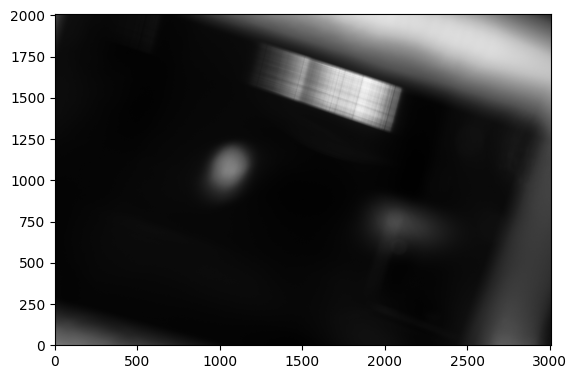

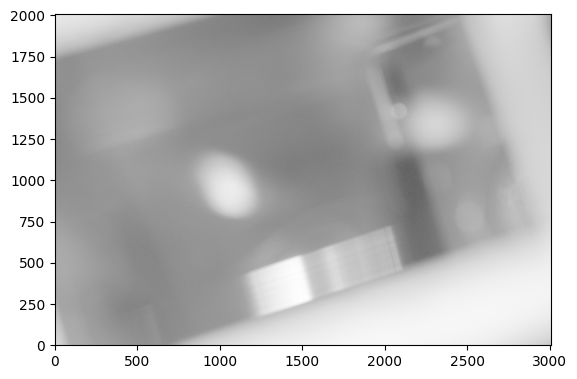

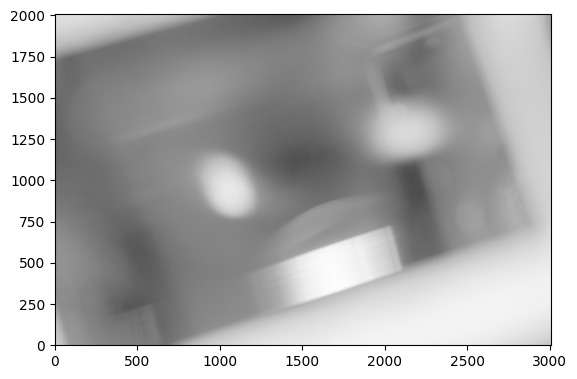

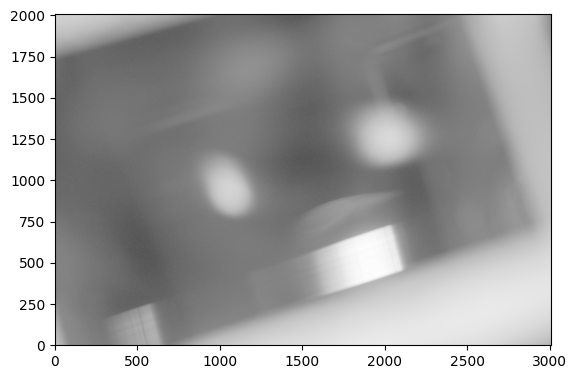

In [3]:
r,g,b = im.load_image('./Solar_Spectroscopy/DSC_0072.NEF', print_log="True", stretch="linear")
red = im.flip(r, axis="y")
green = im.flip(g, axis="y")
blue = im.flip(b, axis="y")
im.display(red)
im.display(green)
im.display(blue)

In [4]:
# colours = [red,green,blue]
# stack = im.stack(colours)
# im.display(stack)

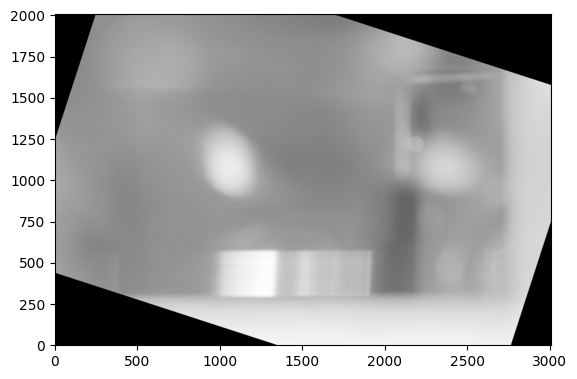

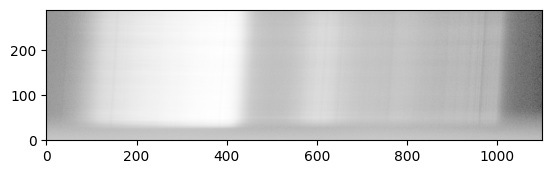

In [5]:
redangled = spec.rotate_spectrum(red, angle=18, origin=None, threshold=0.1, expand=False, fill=False, print_log=True)
redcrop = im.crop(redangled, left=900, right=2000, top=550, bottom=260, origin=None, print_log=True, fig=None, ax=None)

Text(0, 0.5, 'Intensity')

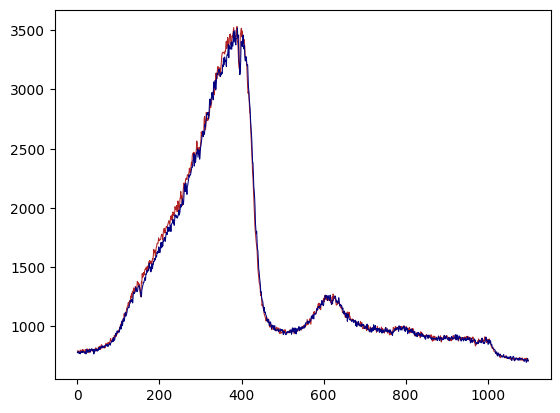

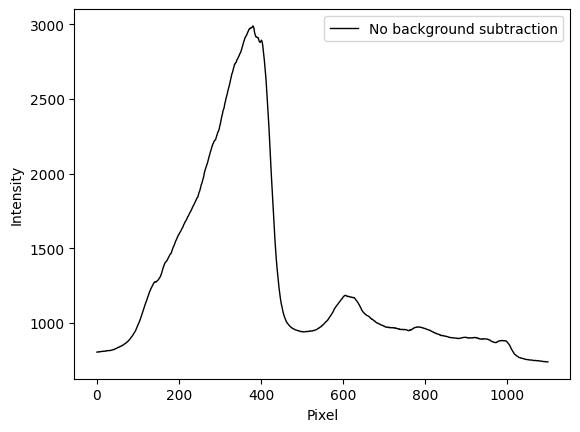

In [24]:
plt.plot(redcrop[200], color='firebrick', lw=0.75)
plt.plot(redcrop[230], color='navy', lw=0.75)
redspec = spec.get_spectrum(redcrop, print_log=True)

plt.xlabel("Pixel")
plt.ylabel("Intensity")



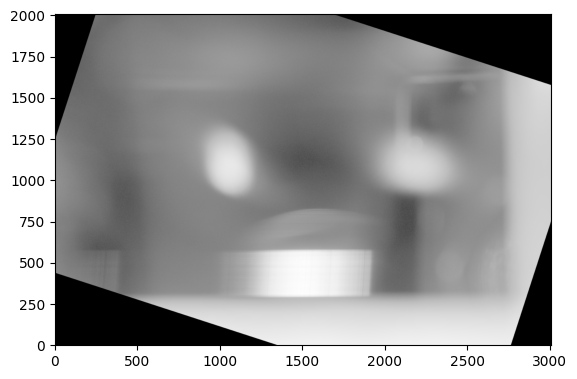

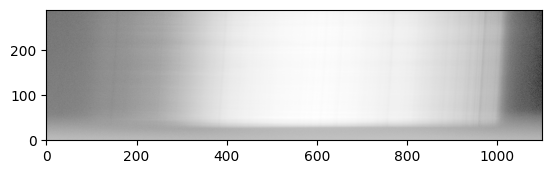

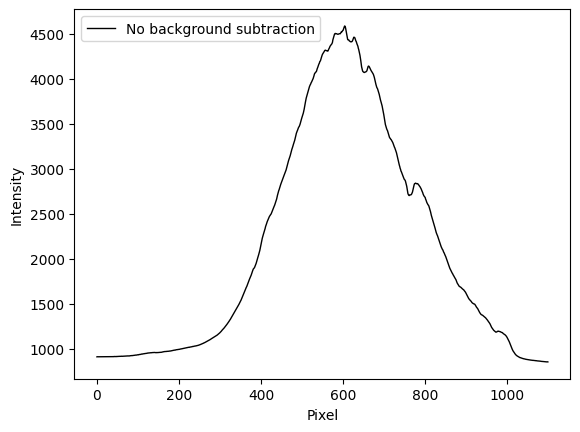

In [7]:
greenangled = spec.rotate_spectrum(green, angle=18, origin=None, threshold=0.1, expand=False, fill=False, print_log=True)
greencrop = im.crop(greenangled, left=900, right=2000, top=550, bottom=260, origin=None, print_log=True, fig=None, ax=None)
greenspec = spec.get_spectrum(greencrop, print_log=True)

Text(0, 0.5, 'Intensity')

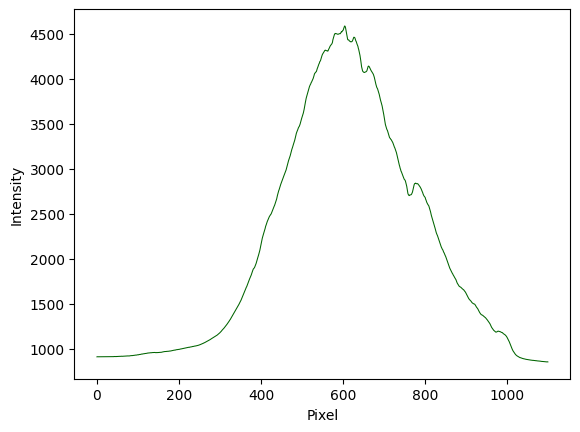

In [8]:
plt.plot(greenspec, color='darkgreen', lw=0.75)

plt.xlabel("Pixel")
plt.ylabel("Intensity")

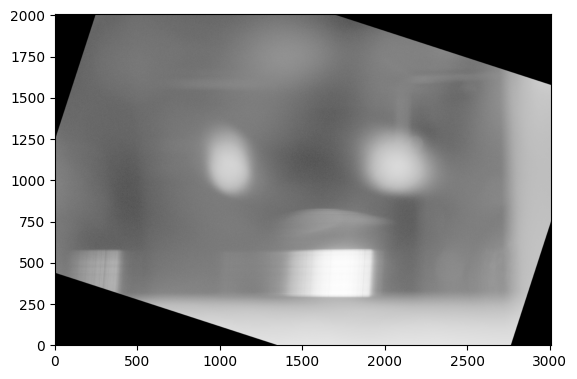

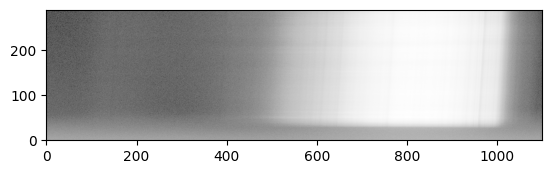

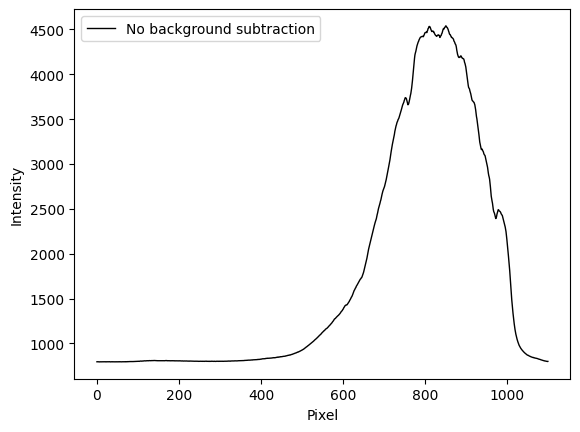

In [9]:
blueangled = spec.rotate_spectrum(blue, angle=18, origin=None, threshold=0.1, expand=False, fill=False, print_log=True)
bluecrop = im.crop(blueangled, left=900, right=2000, top=550, bottom=260, origin=None, print_log=True, fig=None, ax=None)
bluespec = spec.get_spectrum(bluecrop, print_log=True)

Text(0, 0.5, 'Intensity')

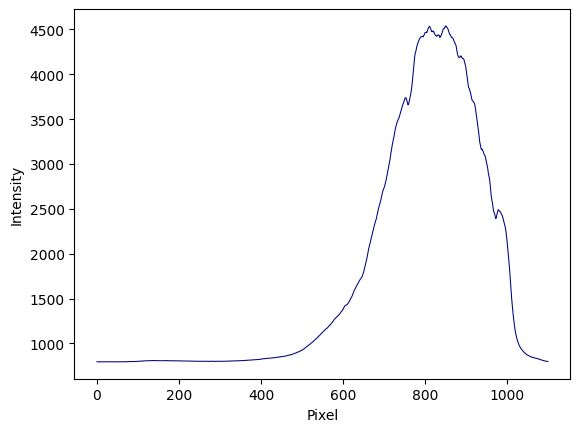

In [10]:
plt.plot(bluespec, color='navy', lw=0.75)


plt.xlabel("Pixel")
plt.ylabel("Intensity")

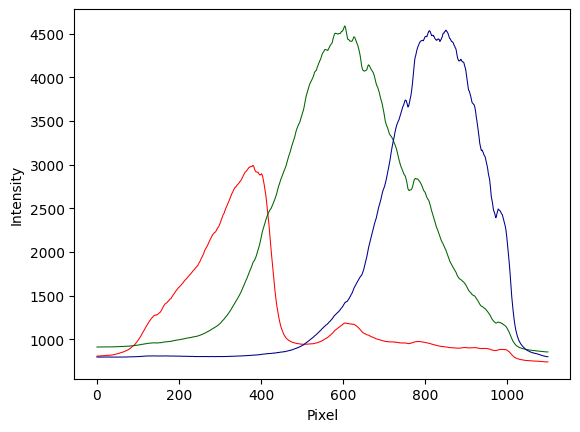

In [25]:
#Stacking the three plots

plt.plot(redspec, color='red', lw=0.75)
#plt.plot(redcrop[230], color='pink', lw=0.75)

plt.plot(greenspec, color='darkgreen', lw=0.75)
#plt.plot(greencrop[230], color='lightgreen', lw=0.75)

plt.plot(bluespec, color='darkblue', lw=0.75)
#plt.plot(bluecrop[230], color='lightblue', lw=0.75)



plt.xlabel("Pixel")
plt.ylabel("Intensity")
plt.savefig("colorintent")

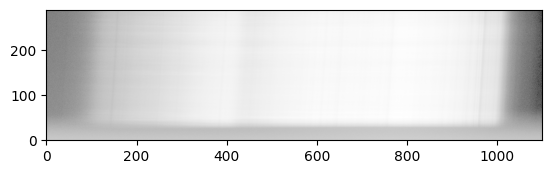

In [12]:
files = [redcrop, greencrop, bluecrop]
stackrgb = im.stack(files)
im.display(stackrgb)

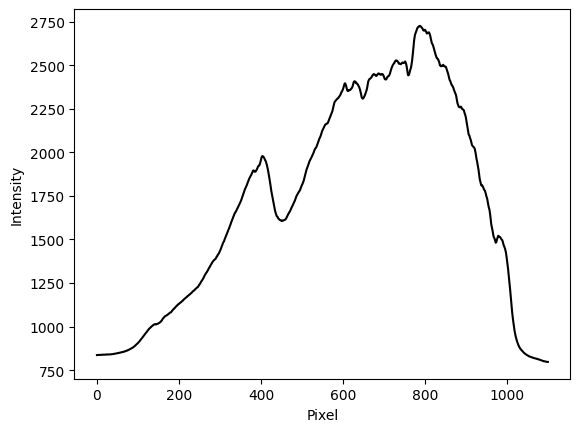

In [27]:
rgbspec = spec.get_spectrum(stackrgb)
plt.plot(rgbspec, color = "black")
plt.xlabel("Pixel")
plt.ylabel("Intensity")
plt.savefig("stacksubtract")

Shape of solar_spec: (1100,)


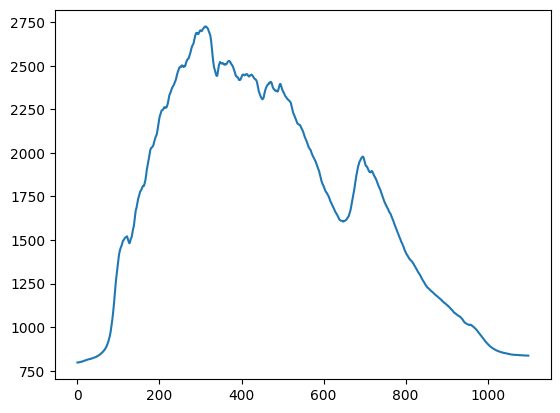

In [14]:
# Check solar_spec dimensions
print("Shape of solar_spec:", rgbspec.shape)

# If it's 1D, use NumPy flip
if rgbspec.ndim == 1:
    flip_s_spec = np.flip(rgbspec)  # Best for 1D arrays
else:
    # If it's 2D, try flipping along the width
    flip_s_spec = im.flip(rgbspec, axis=1)

plt.plot(flip_s_spec)

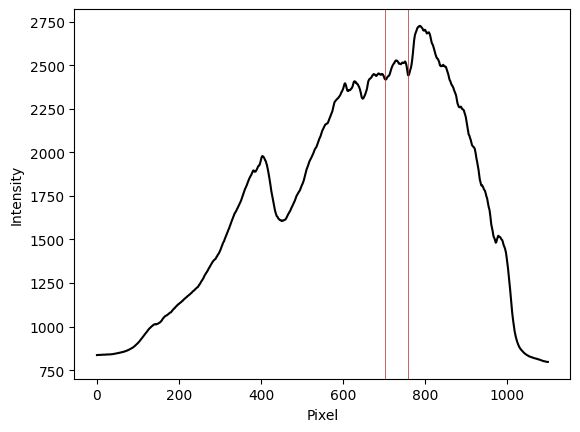

In [28]:
wavelengths, AngstromsPerPix = spec.calibrate(rgbspec, lineA=[757,5186.2], lineB=[701, 5270.39], print_log=True)
plt.savefig("speccalibrate")

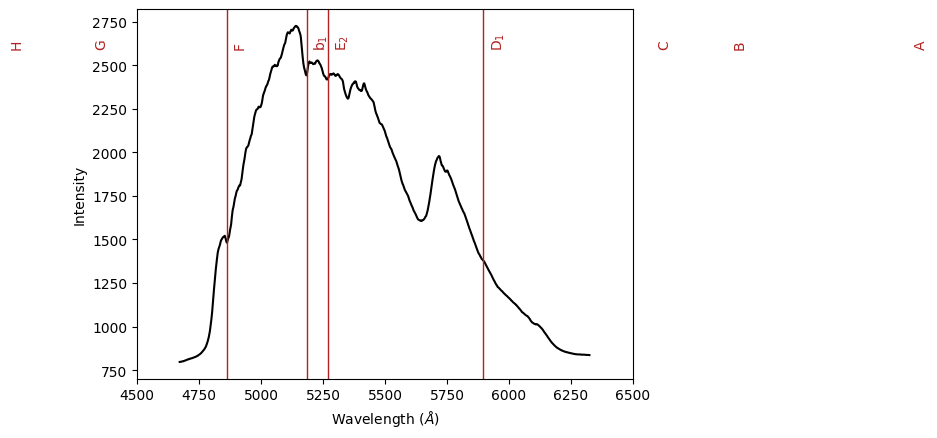

In [29]:
fig, ax = plt.subplots() 

ax.plot(wavelengths, rgbspec, color='k')  
spec.plot_fraunhofer(fig=fig, ax=ax, lw=1)
plt.xlim(4500, 6500)
plt.xlabel("Wavelength ($\AA$)")
plt.ylabel("Intensity")
plt.savefig("specwave")

In [17]:
import numpy as np

peak_index = np.argmax(rgbspec)  
peak_wavelength = wavelengths[peak_index] 

print(f"Peak intensity occurs at wavelength: {peak_wavelength} Å")


Peak intensity occurs at wavelength: 5141.098214285714 Å


In [18]:
lambda_max_A = 5141.098214285714  


lambda_max_m = lambda_max_A * 1e-10  # 1 Å = 1e-10 meters


b = 2.897e-3  

sun_temp = b / lambda_max_m  

print(f"Estimated surface temperature of the Sun: {sun_temp:.2f} K")


Estimated surface temperature of the Sun: 5634.98 K
